# Previsão do Preço da Gasolina — SimpleRNN x GRU x LSTM

Trabalho de Deep Learning — Frente 3.2 (Redes Recorrentes). Fonte: Série Histórica de Preços de Combustíveis da ANP (agregado semanal nacional). Este notebook segue a ordem de execução do enunciado: validação do BinEXT, carregamento, exploração, preparação da série, divisão cronológica, normalização, geração de janelas, baseline, treinamento das três arquiteturas, comparação de janelas/unidades/camadas, regularização, resultados finais e gráficos.

## 1. Verificação do BinEXT

In [1]:
import sys
sys.path.insert(0, '..')
from src import config
config.validate_external_drive()

[BinEXT] Unidade montada em /Volumes/BinEXT
[BinEXT] DATA_ROOT = /Volumes/BinEXT/datasets/anp_combustiveis
[BinEXT] Espaço livre: 808.69 GB de 931.48 GB


In [15]:
%matplotlib inline
# Garante backend inline mesmo após módulos internos (src.evaluation) usarem Agg para execução via script.

## 2. Carregamento dos dados brutos da ANP

In [2]:
from src.data_loader import load_combined_raw
raw = load_combined_raw()
print(raw.shape)
raw.head()

[BinEXT] Unidade montada em /Volumes/BinEXT
[BinEXT] DATA_ROOT = /Volumes/BinEXT/datasets/anp_combustiveis
[BinEXT] Espaço livre: 808.69 GB de 931.48 GB
[data_loader] Arquivo já existente, reutilizando: /Volumes/BinEXT/datasets/anp_combustiveis/raw/semanal-brasil-2004-a-2012.xlsx
[data_loader] Arquivo já existente, reutilizando: /Volumes/BinEXT/datasets/anp_combustiveis/raw/semanal-brasil-desde-2013.xlsx
(6778, 17)


,DATA INICIAL,DATA FINAL,PRODUTO,NUMERO DE POSTOS PESQUISADOS,UNIDADE DE MEDIDA,PRECO MEDIO REVENDA,DESVIO PADRAO REVENDA,PRECO MINIMO REVENDA,PRECO MAXIMO REVENDA,MARGEM MEDIA REVENDA,COEF DE VARIACAO REVENDA,PRECO MEDIO DISTRIBUICAO,DESVIO PADRAO DISTRIBUICAO,PRECO MINIMO DISTRIBUICAO,PRECO MAXIMO DISTRIBUICAO,COEF DE VARIACAO DISTRIBUICAO,__source_file__
0,2004-05-09,2004-05-15,ETANOL HIDRATADO,11472,R$/l,1.283,0.268,0.590,2.400,0.38,0.209,0.903,0.192,0.326,1.8908,0.213,semanal-brasil-2004-a-2012.xlsx
1,2004-05-09,2004-05-15,GASOLINA COMUM,12442,R$/l,2.083,0.142,1.570,2.850,0.328,0.068,1.755,0.079,1.38,2.188,0.045,semanal-brasil-2004-a-2012.xlsx
2,2004-05-09,2004-05-15,GLP,7199,R$/13Kg,32.199,2.363,22.990,45.000,5.703,0.073,26.496,2.439,19.19,38.0,0.092,semanal-brasil-2004-a-2012.xlsx
3,2004-05-09,2004-05-15,GNV,537,R$/m3,1.130,0.082,0.849,1.288,0.323,0.073,0.807,0.158,0.4214,1.02,0.196,semanal-brasil-2004-a-2012.xlsx
4,2004-05-09,2004-05-15,OLEO DIESEL,10567,R$/l,1.438,0.079,1.180,1.900,0.175,0.055,1.263,0.055,1.0029,1.549,0.044,semanal-brasil-2004-a-2012.xlsx


## 3. Exploração inicial

In [3]:
print('Produtos disponíveis:', raw['PRODUTO'].unique())
print('Período:', raw['DATA INICIAL'].min(), 'a', raw['DATA INICIAL'].max())
print('Valores ausentes por coluna:')
print(raw.isna().sum())
print('Linhas duplicadas (DATA INICIAL, PRODUTO):', raw.duplicated(subset=['DATA INICIAL','PRODUTO']).sum())

Produtos disponíveis: <ArrowStringArray>
[  'ETANOL HIDRATADO',     'GASOLINA COMUM',                'GLP',
                'GNV',        'OLEO DIESEL',    'OLEO DIESEL S10',
 'GASOLINA ADITIVADA']
Length: 7, dtype: str
Período: 2004-05-09 00:00:00 a 2026-09-06 00:00:00
Valores ausentes por coluna:
DATA INICIAL                     0
DATA FINAL                       0
PRODUTO                          0
NUMERO DE POSTOS PESQUISADOS     0
UNIDADE DE MEDIDA                0
PRECO MEDIO REVENDA              0
DESVIO PADRAO REVENDA            0
PRECO MINIMO REVENDA             0
PRECO MAXIMO REVENDA             0
MARGEM MEDIA REVENDA             0
COEF DE VARIACAO REVENDA         0
PRECO MEDIO DISTRIBUICAO         0
DESVIO PADRAO DISTRIBUICAO       0
PRECO MINIMO DISTRIBUICAO        0
PRECO MAXIMO DISTRIBUICAO        0
COEF DE VARIACAO DISTRIBUICAO    0
__source_file__                  0
dtype: int64
Linhas duplicadas (DATA INICIAL, PRODUTO): 0


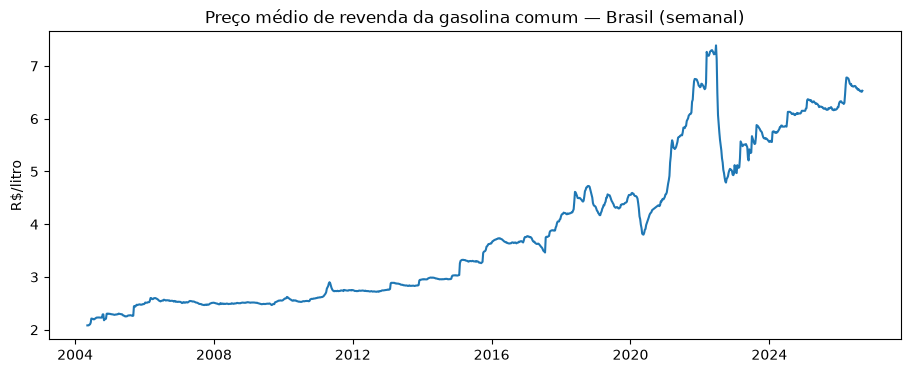

In [4]:
import matplotlib.pyplot as plt
gasolina = raw[raw['PRODUTO']=='GASOLINA COMUM'].set_index('DATA INICIAL').sort_index()
fig, ax = plt.subplots(figsize=(11,4))
ax.plot(gasolina.index, gasolina['PRECO MEDIO REVENDA'])
ax.set_title('Preço médio de revenda da gasolina comum — Brasil (semanal)')
ax.set_ylabel('R$/litro')
plt.show()

In [5]:
gasolina['PRECO MEDIO REVENDA'].describe()

count    1153.000000
mean        3.836088
std         1.444658
min         2.083000
25%         2.554000
50%         3.303000
75%         4.860000
max         7.390000
Name: PRECO MEDIO REVENDA, dtype: float64

## 4. Preparação da série semanal nacional (features + alvo)

In [6]:
from src.preprocessing import build_processed_dataset, run_data_quality_checks
df = build_processed_dataset()
df.head()

[BinEXT] Unidade montada em /Volumes/BinEXT
[BinEXT] DATA_ROOT = /Volumes/BinEXT/datasets/anp_combustiveis
[BinEXT] Espaço livre: 808.69 GB de 931.48 GB
[data_loader] Arquivo já existente, reutilizando: /Volumes/BinEXT/datasets/anp_combustiveis/raw/semanal-brasil-2004-a-2012.xlsx
[data_loader] Arquivo já existente, reutilizando: /Volumes/BinEXT/datasets/anp_combustiveis/raw/semanal-brasil-desde-2013.xlsx
[preprocessing] Aviso: 4 lacunas na periodicidade semanal (gap modal=7 days 00:00:00); maiores gaps:
data_inicial
2020-10-18   63 days
2005-08-28   21 days
2009-08-30   21 days
2015-08-23   14 days
Name: data_inicial, dtype: timedelta64[us]
[preprocessing] OK: 1152 semanas, 8 features, sem NaN, sem duplicatas
[preprocessing] Dataset processado salvo em /Volumes/BinEXT/datasets/anp_combustiveis/processed/serie_semanal_nacional.parquet


,gasolina_preco_medio,gasolina_preco_minimo,gasolina_preco_maximo,gasolina_desvio_padrao,gasolina_coef_variacao,gasolina_num_postos,etanol_preco_medio,diesel_preco_medio,target_gasolina_t_plus_1
data_inicial,,,,,,,,,
2004-05-09,2.083,1.570,2.85,0.142,0.068,12442,1.283,1.438,2.083
2004-05-16,2.083,1.540,2.85,0.145,0.070,12503,1.279,1.439,2.084
2004-05-23,2.084,1.570,2.85,0.142,0.068,12555,1.288,1.440,2.096
2004-05-30,2.096,1.529,2.85,0.137,0.065,12507,1.323,1.442,2.103
2004-06-06,2.103,1.580,2.85,0.135,0.064,12536,1.340,1.442,2.134


## 5. Divisão cronológica (treino/validação/teste)

In [7]:
from src.preprocessing import chronological_split
train_df, val_df, test_df = chronological_split(df)
assert train_df.index.max() < val_df.index.min()
assert val_df.index.max() < test_df.index.min()
print('OK: sem sobreposição temporal entre partições')

[preprocessing] Split cronológico -> treino: 2004-05-09 a 2019-11-17 (806 semanas); validação: 2019-11-24 a 2023-04-30 (172); teste: 2023-05-07 a 2026-08-30 (174)
OK: sem sobreposição temporal entre partições


## 6. Normalização (StandardScaler ajustado somente no treino)

In [8]:
from src.preprocessing import fit_scalers, apply_scalers
feature_scaler, target_scaler = fit_scalers(train_df)
X_train, y_train = apply_scalers(train_df, feature_scaler, target_scaler)
print(X_train.shape, y_train.shape)

(806, 8) (806, 1)


## 7. Geração das janelas temporais (create_sequences)

In [9]:
from src.sequences import create_sequences
X_seq, y_seq = create_sequences(X_train, y_train, window_size=12)
print('X:', X_seq.shape, 'y:', y_seq.shape)

X: (795, 12, 8) y: (795, 1)


## 8. Baseline de persistência

In [10]:
from src.training import persistence_baseline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
base = persistence_baseline()
for split in ('train','val','test'):
    y_true, y_pred = base[split]
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'{split}: MAE={mae:.4f} RMSE={rmse:.4f} R2={r2:.4f}')

[preprocessing] Split cronológico -> treino: 2004-05-09 a 2019-11-17 (806 semanas); validação: 2019-11-24 a 2023-04-30 (172); teste: 2023-05-07 a 2026-08-30 (174)
train: MAE=0.0104 RMSE=0.0241 R2=0.9987
val: MAE=0.0583 RMSE=0.1040 R2=0.9888
test: MAE=0.0256 RMSE=0.0528 R2=0.9771


## 9-11. SimpleRNN, GRU e LSTM (janela de 12 semanas, unidades=64)

Demonstração ilustrativa das três arquiteturas com a mesma janela. A grade completa
de experimentos (3 janelas x 3 arquiteturas, unidades, profundidade, regularização e
busca Optuna) foi executada via `python -m src.run_experiments` e consolidada em
`results/experiments.csv` (ver seções 12-15 abaixo).

In [11]:
from src.training import train_experiment
from src.evaluation import regression_metrics

demo_results = {}
for cell_type in ('SimpleRNN', 'GRU', 'LSTM'):
    result, art = train_experiment(cell_type, window_size=12, units=64, dropout=0.2, verbose=0)
    val_metrics = regression_metrics(art['y_val'], art['y_val_pred'], art['target_scaler'])
    demo_results[cell_type] = (result, val_metrics)
    print(cell_type, '-> params:', result['n_params'], 'epocas:', result['n_epochs_run'],
          'tempo(s):', round(result['train_time_seconds'],1), 'val MAE:', round(val_metrics['mae'],4),
          'val RMSE:', round(val_metrics['rmse'],4), 'val R2:', round(val_metrics['r2'],4))

[preprocessing] Split cronológico -> treino: 2004-05-09 a 2019-11-17 (806 semanas); validação: 2019-11-24 a 2023-04-30 (172); teste: 2023-05-07 a 2026-08-30 (174)
SimpleRNN -> params: 4737 epocas: 47 tempo(s): 4.3 val MAE: 0.6852 val RMSE: 0.8844 val R2: 0.1883
[preprocessing] Split cronológico -> treino: 2004-05-09 a 2019-11-17 (806 semanas); validação: 2019-11-24 a 2023-04-30 (172); teste: 2023-05-07 a 2026-08-30 (174)
GRU -> params: 14273 epocas: 33 tempo(s): 5.2 val MAE: 0.7655 val RMSE: 1.0491 val R2: -0.142
[preprocessing] Split cronológico -> treino: 2004-05-09 a 2019-11-17 (806 semanas); validação: 2019-11-24 a 2023-04-30 (172); teste: 2023-05-07 a 2026-08-30 (174)
LSTM -> params: 18753 epocas: 76 tempo(s): 9.2 val MAE: 0.6122 val RMSE: 0.7804 val R2: 0.368


## 12-14. Comparação de janelas, unidades/camadas e regularização (resultados completos)

In [12]:
import pandas as pd
experiments = pd.read_csv('../results/experiments.csv')
experiments.sort_values('mae_val').head(15)

,tag,modelo,janela,unidades,camadas,dropout,l2,parametros,epocas,mae_val,rmse_val,r2_val,tempo_treino_s,tempo_por_epoca_s,mae_test,rmse_test,r2_test
0,baseline,Persistencia,1,NaN,NaN,NaN,NaN,0,NaN,0.058326,0.103957,0.988786,0.000000,0.000000,NaN,NaN,NaN
21,regularizacao,LSTM,12,64.0,1.0,0.000000,0.001,18753,100.0,0.299905,0.450718,0.789206,16.595258,0.165953,0.334316,0.362787,-0.080006
22,optuna_best,LSTM,12,96.0,1.0,0.037061,0.000,40417,86.0,0.345865,0.484771,0.756151,12.272115,0.142699,0.393147,0.419346,-0.443002
19,regularizacao,LSTM,12,64.0,1.0,0.000000,0.000,18753,83.0,0.422353,0.620408,0.600605,9.233357,0.111245,0.512920,0.549434,-1.477157
14,unidades,GRU,12,128.0,1.0,0.200000,0.000,53121,23.0,0.454505,0.657876,0.550907,4.944488,0.214978,0.602556,0.638432,-2.344652
12,unidades,SimpleRNN,12,128.0,1.0,0.200000,0.000,17665,22.0,0.530588,0.796402,0.341868,2.673449,0.121520,0.753021,0.803905,-4.303117
16,unidades,LSTM,12,128.0,1.0,0.200000,0.000,70273,22.0,0.536726,0.769243,0.385990,4.771021,0.216865,0.701147,0.743396,-3.534847
7,principal,LSTM,12,64.0,1.0,0.200000,0.000,18753,76.0,0.612168,0.780408,0.368037,8.683432,0.114256,0.715644,0.741549,-3.512341
20,regularizacao,LSTM,12,64.0,1.0,0.400000,0.000,18753,45.0,0.655509,0.869425,0.215645,8.964790,0.199218,0.847261,0.877199,-5.314197
2,principal,SimpleRNN,4,64.0,1.0,0.200000,0.000,4737,48.0,0.678206,0.896049,0.166873,3.618359,0.075382,0.949128,0.984854,-6.959123


In [13]:
principal = experiments[experiments['tag']=='principal']
pivot_mae = principal.pivot(index='janela', columns='modelo', values='mae_val')
pivot_mae

modelo,GRU,LSTM,SimpleRNN
janela,,,
4,0.747846,0.771449,0.678206
12,0.765482,0.612168,0.685246
26,0.746892,0.699518,0.703901


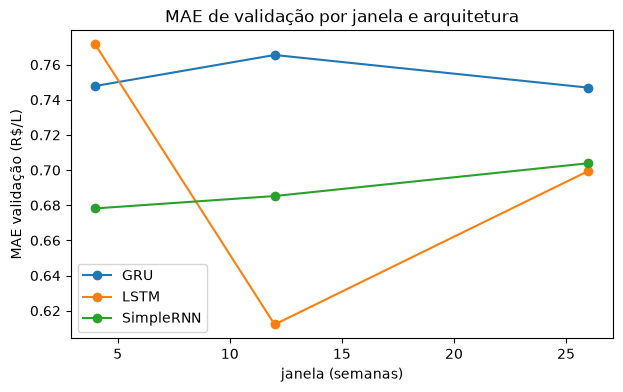

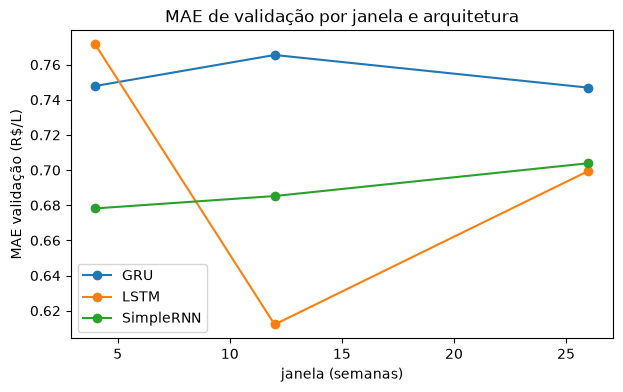

In [16]:
fig, ax = plt.subplots(figsize=(7,4))
for modelo in pivot_mae.columns:
    ax.plot(pivot_mae.index, pivot_mae[modelo], marker='o', label=modelo)
ax.set_xlabel('janela (semanas)')
ax.set_ylabel('MAE validação (R$/L)')
ax.set_title('MAE de validação por janela e arquitetura')
ax.legend()
plt.show()

## 15-16. Resultados finais e gráficos (real x previsto, resíduos)

In [17]:
experiments.sort_values('mae_val').head(3)[[
    'tag','modelo','janela','unidades','camadas','dropout','l2','parametros','epocas',
    'mae_val','rmse_val','r2_val','mae_test','rmse_test','r2_test','tempo_treino_s'
]]

,tag,modelo,janela,unidades,camadas,dropout,l2,parametros,epocas,mae_val,rmse_val,r2_val,mae_test,rmse_test,r2_test,tempo_treino_s
0,baseline,Persistencia,1,NaN,NaN,NaN,NaN,0,NaN,0.058326,0.103957,0.988786,NaN,NaN,NaN,0.000000
21,regularizacao,LSTM,12,64.0,1.0,0.000000,0.001,18753,100.0,0.299905,0.450718,0.789206,0.334316,0.362787,-0.080006,16.595258
22,optuna_best,LSTM,12,96.0,1.0,0.037061,0.000,40417,86.0,0.345865,0.484771,0.756151,0.393147,0.419346,-0.443002,12.272115


Os gráficos de curvas de treino/validação, real x previsto e resíduos para as
configurações-chave estão salvos em `results/figures/` (gerados por `run_experiments.py`).

## 17. Análise final

Ver discussão completa e fundamentada nos resultados reais em [`report/resultados.md`](../report/resultados.md).